In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("WP.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
#undersatnd Data
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.isnull().sum())

         ph    Hardness       Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890456  20791.31898     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.05786     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.54173     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.41744     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.98634     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436525       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           -

In [5]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [3]:
df["ph"]=df["ph"].fillna(df["ph"].mean())
df["Sulfate"]=df["Sulfate"].fillna(df["Sulfate"].mean())
df["Trihalomethanes"]=df["Trihalomethanes"].fillna(df["Trihalomethanes"].mean())

In [7]:
df.isnull().sum()


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [5]:
#feature selection
x=df[["ph","Solids","Sulfate"]]
y=df["Potability"]


In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [7]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

x_scaled_train, x_scaled_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

In [8]:
#model training
from sklearn.tree import DecisionTreeClassifier
dt_cl=DecisionTreeClassifier(criterion="gini",max_depth=4,random_state=42)
model_dt=dt_cl.fit(x_scaled_train,y_train)


In [9]:
#model prediction
y_pred=model_dt.predict(x_scaled_test)

In [10]:
#model evalution
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
a_s=accuracy_score(y_test,y_pred)
c_m=confusion_matrix(y_test,y_pred,labels=["0","1"])
c_m_r=classification_report(y_test,y_pred)
print("accuracy:",a_s)
print("confusion_matrix:",c_m)
print("classification_report:",c_m_r)

accuracy: 0.6478658536585366
confusion_matrix: [[0 0]
 [0 0]]
classification_report:               precision    recall  f1-score   support

           0       0.66      0.90      0.76       412
           1       0.57      0.22      0.31       244

    accuracy                           0.65       656
   macro avg       0.62      0.56      0.54       656
weighted avg       0.63      0.65      0.60       656



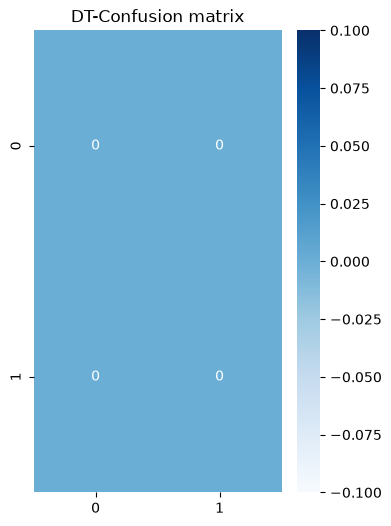

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,6))
sns.heatmap(c_m,annot=True,fmt="d",
            cmap="Blues",xticklabels=[0,1],
            yticklabels=[0,1])
plt.xlabel=("predictd")
plt.ylabel=("Actuals")
plt.title("DT-Confusion matrix")
plt.show()

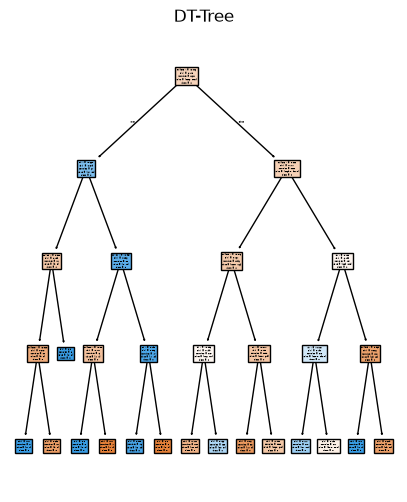

In [12]:
# tree display
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(5,6))
plot_tree(
    model_dt,
    feature_names=x.columns,
    class_names=[str(c) for c in model_dt.classes_],  # convert labels to strings
    filled=True
)
plt.title("DT-Tree")
plt.show()


In [13]:
df["Potability"]=df["Potability"].rename({"0":"No-P","1":"P"})

In [14]:
df["Potability"].unique()

array([0, 1])

In [15]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
